In [1]:
# Importing libraries
import pandas as pd
import numpy as np

In [2]:
# Load the customer shopping data from the CSV file
df=pd.read_csv("customer_shopping_behavior.csv")

In [3]:
df.head(3)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly


In [4]:
# Cleaning up the column names
# Converting column names into snake_case to keep things consistent and easy to work with during analysis
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(' ','_')
df.rename(columns={'purchase_amount_(usd)':'purchase_amount_usd'},inplace=True)

In [5]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             3900 non-null   int64  
 1   age                     3900 non-null   int64  
 2   gender                  3900 non-null   object 
 3   item_purchased          3900 non-null   object 
 4   category                3900 non-null   object 
 5   purchase_amount_usd     3900 non-null   int64  
 6   location                3900 non-null   object 
 7   size                    3900 non-null   object 
 8   color                   3900 non-null   object 
 9   season                  3900 non-null   object 
 10  review_rating           3863 non-null   float64
 11  subscription_status     3900 non-null   object 
 12  shipping_type           3900 non-null   object 
 13  discount_applied        3900 non-null   object 
 14  promo_code_used         3900 non-null   

In [7]:
# Identifying the numerical columns in the data
# Select actual continuous numerical columns, excluding structural IDs
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('customer_id').tolist()
numerical_cols

['age', 'purchase_amount_usd', 'review_rating', 'previous_purchases']

In [8]:
#quick statistical summary of the numerical data
df[numerical_cols].describe()

,age,purchase_amount_usd,review_rating,previous_purchases
count,3900.000000,3900.000000,3863.000000,3900.000000
mean,44.068462,59.764359,3.750065,25.351538
std,15.207589,23.685392,0.716983,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.800000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [9]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
item_purchased             0
category                   0
purchase_amount_usd        0
location                   0
size                       0
color                      0
season                     0
review_rating             37
subscription_status        0
shipping_type              0
discount_applied           0
promo_code_used            0
previous_purchases         0
payment_method             0
frequency_of_purchases     0
dtype: int64

In [10]:
# Fill missing review ratings using the median rating of that specific item category.
# (We use the median here because a few extreme scores won't skew the overall average)
df['review_rating'] = df['review_rating'].fillna(df.groupby('category')['review_rating'].transform('median'))

In [11]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_usd       0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

In [12]:
# Check if there are any completely identical rows in the data
df.duplicated().sum()

0

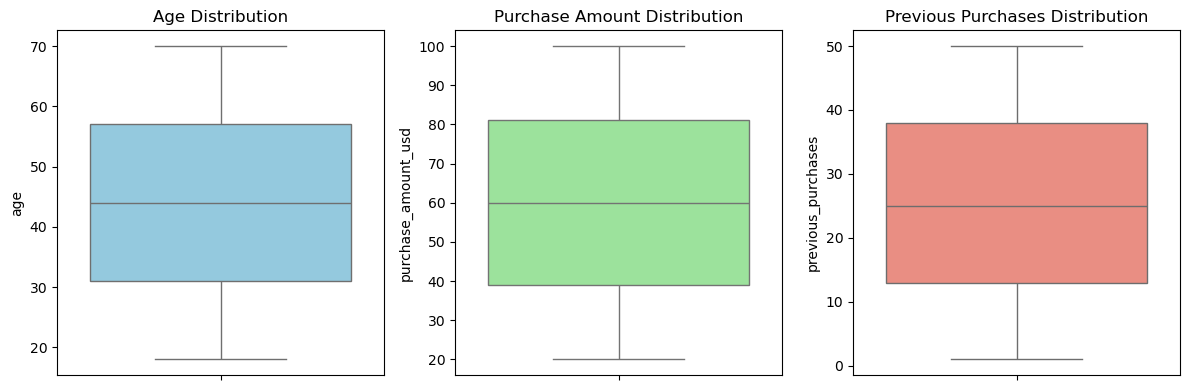

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual check for outliers in key business metrics
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['age'], color='skyblue')
plt.title('Age Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['purchase_amount_usd'], color='lightgreen')
plt.title('Purchase Amount Distribution')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['previous_purchases'], color='salmon')
plt.title('Previous Purchases Distribution')

plt.tight_layout()
plt.show()

In [14]:
# Outlier verification using IQR for numerical columns
numerical_features = ['age', 'purchase_amount_usd', 'previous_purchases']

for col in numerical_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Feature '{col}': Found {len(outliers)} outliers outside standard IQR boundaries.")

Feature 'age': Found 0 outliers outside standard IQR boundaries.
Feature 'purchase_amount_usd': Found 0 outliers outside standard IQR boundaries.
Feature 'previous_purchases': Found 0 outliers outside standard IQR boundaries.


##### After evaluating the distributions both visually (via box plots) and statistically (via the 1.5 times IQR rule), zero outliers were detected across key numerical attributes.

##### Business Context Validation: Features like age (bounded between 18–70) and review_rating (bounded between 1–5) are naturally constrained by collection limits. High values in previous_purchases represent our top-tier, heavy-frequency shoppers rather than malicious or corrupt data entries. Therefore, no data capping or trimming is required, preserving full analytical integrity for our Power BI metrics.

In [16]:
df[['discount_applied','promo_code_used']].head()

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes


In [17]:
# Check if every single row in both columns have the exact same value
(df['discount_applied']==df['promo_code_used']).all()

True

In [18]:
# drop the 'promo_code_used' column since it is just an exact copy of disocunt_applied
df=df.drop(columns='promo_code_used')

#### Both discount_applied and promo_code_used columns carry the exact same information. Dropping one removes redundant data, which keeps our dataset clean and avoids confusion during analysis.

## DATA QUALITY CHECK

In [21]:
# review rating between 1–5?
print('Minimum Value of Review Rating: ',df['review_rating'].min())
print('Maximun Value of Review Rating: ',df['review_rating'].max())

Minimum Value of Review Rating:  2.5
Maximun Value of Review Rating:  5.0


In [22]:
# Returns True if there are negatives, False if there are none
(df['purchase_amount_usd'] < 0).any()

False

In [23]:
# previous purchases negative?
(df['previous_purchases']<0).any()

False

In [24]:
# subscription values consistent?
df['subscription_status'].unique()

array(['Yes', 'No'], dtype=object)

## FEATURE ENGINEERING

In [26]:
# age_group - breaks down customer ages into life-stage generations
# young adult: Fresh consumers and young shoppers up to 30 years old
# adult: Core working professionals aged 31 to 45
# middle aged: Established adults with stable preferences aged 46 to 60
# senior: Older generations and mature shoppers over 60 years old

In [27]:
age_group_bins = [0, 30, 45, 60, np.inf]
age_group_labels = ['young adult', 'adult', 'middle aged', 'senior']
# Apply pd.cut to create the column
df['age_group'] = pd.cut(df['age'], bins=age_group_bins, labels=age_group_labels)

#### Grouping ages makes it easy to spot shopping trends across different generations and target marketing to the right audience.

In [29]:
# purchase_frequency_days - maps text habits to the exact number of days between purchases
# Weekly / Fortnightly / Bi-Weekly: Frequent shoppers returning every 7 to 14 days
# Monthly / Quarterly / Every 3 Months: Regular interval shoppers returning every 30 to 90 days
# Annually: Seasonal or once-a-year buyers returning every 365 days

In [30]:
# create column purchase frequency days 
frequency_day_mapping={
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}
df['purchase_frequency_days']=df['frequency_of_purchases'].map(frequency_day_mapping)

#### Converting shopping frequencies into exact numbers lets us track the actual days between visits, making it easy to identify how often different customers buy and who our most active shoppers are.

In [32]:
# order_value_segment - rules for single transactions based on the current checkout total
# Low-Value Order: Small or budget purchases up to $30
# Mid-Value Order: shopping carts between $31 and $70
# High-Value Order: Larger, more significant investments between $71 and $100
# Premium-Value Order: High-ticket baskets totaling over $100

In [33]:
order_bins = [0, 30, 70, 100, np.inf]
order_labels = ['Low-Value Order', 'Mid-Value Order', 'High-Value Order', 'Premium-Value Order']
df['order_value_segment'] = pd.cut(df['purchase_amount_usd'], bins=order_bins, labels=order_labels)

#### Grouping single purchases into price tiers lets us categorize the value of this specific transaction.It helps the business see which  price brackets drive the most immediate revenue, though it reflects just this current receipt rather than the customer's total                lifetime spending history.

In [35]:
# loyalty_segment - based on previous purchase history

# New Buyer: <= 1 purchase
# Occasional Shopper: 2–10 purchases
# Regular Shopper: 11–25 purchases
# Loyal Shopper: 26–40 purchases
# Top Tier Shopper: > 40 purchases

In [36]:
conditions = [

    # Almost first-time buyers
    (df['previous_purchases'] <= 1),

    # Low repeat customers
    (df['previous_purchases'] > 1) &
    (df['previous_purchases'] <= 10),

    # Consistent repeat shoppers
    (df['previous_purchases'] > 10) &
    (df['previous_purchases'] <= 25),

    # Strong loyal customers
    (df['previous_purchases'] > 25) &
    (df['previous_purchases'] <= 40),

    # Extremely loyal / high retention customers
    (df['previous_purchases'] > 40)
]

choices = [
    'New Buyer',
    'Occasional Shopper',
    'Regular Shopper',
    'Loyal Shopper',
    'Top Tier Shopper'
]

df['loyalty_segment'] = np.select(
    conditions,
    choices
)

#### Unlike the single transaction value, this column looks at their long-term history. It lets us separate brand-new faces from our most dedicated regulars, which is perfect for designing loyalty rewards or win-back campaigns.

In [38]:
# engagement_segment - rules for engagement is based on how often they buy, past orders, and subscriptions
# High: Buys at least every 15 days, has 15+ past purchases, AND has an active subscription
# Moderate: Buys at least once a month and has at least 8 past purchases
# and anyone else to 'Low Engagement

In [39]:
high_engagement_threshold = 15
moderate_engagement_threshold = 8

conditions = [
    ((df['purchase_frequency_days'] <= 15) & (df['previous_purchases'] >= high_engagement_threshold) & (df['subscription_status'] == 'Yes')),
    ((df['purchase_frequency_days'] <= 30) & (df['previous_purchases'] >= (moderate_engagement_threshold)))
]

choices = [
    'High Engagement', 
    'Moderate Engagement' 
]

df['engagement_segment'] = np.select(conditions, choices, default='Low Engagement')

#### This combines how often a customer visits, their lifetime history, and their subscription status into one master score. It helps the business pinpoint of customer interaction so we can protect our high-value shoppers and nudge the low-engagement ones.

In [41]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days',
       'order_value_segment', 'loyalty_segment', 'engagement_segment'],
      dtype='object')

In [42]:
# df.to_csv('customer_behaviour_analysis_cleaned_data.csv',index=False)

In [43]:
# Creating a new dataframe with cleaned data
# df.to_csv('customer_behaviour_analysis_cleaned_data.csv',index=False)
df_clean=df.copy()

In [44]:
# Drop the redundant text column since we already converted it to numbers ('purchase_frequency_days')
# Keeping both stores the exact same data twice, which breaks database normalization rules.
df_clean.drop(columns=['frequency_of_purchases'],inplace=True)

In [45]:
df_clean.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,...,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,age_group,purchase_frequency_days,order_value_segment,loyalty_segment,engagement_segment
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,14,Venmo,middle aged,14,Mid-Value Order,Regular Shopper,Moderate Engagement
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,2,Cash,young adult,14,Mid-Value Order,Occasional Shopper,Low Engagement
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,23,Credit Card,middle aged,7,High-Value Order,Regular Shopper,High Engagement
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,49,PayPal,young adult,7,High-Value Order,Top Tier Shopper,High Engagement
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,31,PayPal,adult,365,Mid-Value Order,Loyal Shopper,Low Engagement


In [46]:
df_clean.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_usd', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method', 'age_group',
       'purchase_frequency_days', 'order_value_segment', 'loyalty_segment',
       'engagement_segment'],
      dtype='object')

In [ ]:
!pip install pymysql sqlalchemy

In [ ]:
from sqlalchemy import create_engine

# MySQL connection
username = "root"
password = "12345"
host = "localhost"
port = "3306"
database ="customer_behavior"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "customers"   # choose any table name
df_clean.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM customers LIMIT 5;", engine)